---

#University of Stirling - Spring 2023

## ITNPAI1 - Deep Learning for Vision and NLP (2022/3)

---

# Resit Assignment Summary

In this activity, you are required to apply the knowledge acquired in this module through the design and development of a complete project for deep learning-based image pattern recognition in an application to be defined by yourself. For this, you will need to perform the following steps:

1. [Problem definition](#scrollTo=hglJVRRslqMn)
2. [GitHub repository](#scrollTo=ecxDhkV9qmUf)
3. [Dataset](#scrollTo=qEgFzxmWrGA9)
4. [Dataloader](#scrollTo=EDd6lLwlx4un)
5. [Proposed solution](#scrollTo=ScTrpUW8zOp4)
6. [Experimental tests and evaluations](#scrollTo=3RBW58of0ZDo)
7. [Quiz and Report](#scrollTo=ws14iV4Dp_vf)


---

# 1. **Problem definition**


You must choose a computer vision task (classification, detection or semantic segmentation) to be modeled from images collected from two different geographic locations (A and B). It can be different neighbourhoods in the same city.
 - The standard project recommendation is to focus on recognizing cars or trees, which are easier to identify and annotate. Other objects or phenomena can be adopted, but are subject to prior approval by the module instructor (Jefersson A. dos Santos). **It is not allowed to assemble datasets containing people. Other sensitive patterns, such as license plates, must be properly hidden.**

[top](#scrollTo=4i5afvUbhmGo)


---
# 2. **GitHub repository**

Give your project a name, create a private [GitHub repository](https://github.com/) with the name [Module Code] + [Project Name] and give access to the module instructors. Create a cover page with a description of your project. This empty notebook must be uploaded in the repository as well as the created dataset. The checkpoint date to perform this task will be two weeks after the publication of this notebook.
This notebook should be updated and committed to the repository according to the checkpoint dates.
The repository's update history will be used as a criterion for monitoring and evaluating the work.
**Check the videos provided in the extra section on Canvas for more details on how to create your GitHub repository.**

[top](#scrollTo=4i5afvUbhmGo)

---
# 3. **Dataset creation**

You must collect a minimum of **200 positive samples** from the study objects for each location (A and B).
Note that, depending on the task being solved, it will also be necessary to:

   (i) collect more samples - negative ones, for instance;

   (ii) annotating each image, delineating objects or creating bounding boxes. Planning and executing this correctly is important to ensure effective training of deep learning-based models.

Your dataset can be assembled from one or more of the following ways:

  - *M1* - Pictures taken by yourself on site (street view from cities A and B), with attention to anonymization issues (if it is the case). It is not allowed to assemble datasets containing people. Other sensitive patterns, such as license plates, must be properly hidden.

  - *M2* - Aerial satellite/drone images obtained from GIS and remote sensing platforms or public repositories. Be careful with unusual file formats that may be challenging to manipulate using basic image processing libraries. We recommend keeping or converting the images to jpg or png.

  - *M3* - Pictures taken from other public available datasets. Remember you are not allowed to use datasets containing people or other sensitive patterns/objects.

  - *M4* - Images crawled from the internet as a whole (social networks, webpages, etc), with special attention to use and copyrights.

  - *M5* - Textual and metadata you may need in your project, with special attention to use and copyrights (as always!).

**Important:** If you collect the images on your own or from aerial imagery repositories, it will be necessary to keep the geographic coordinates. If you collect from specific websites, please retain the source links. This information should be placed in a .csv file and made available along with the final dataset.

[top](#scrollTo=4i5afvUbhmGo)

---

# 4. **Dataloader**

Here you are required to implement all the code related to pre-processing, cleaning, de-noising and preparing the input images and metadata according to the necessary data structures as input to your pattern recognition module. We recommend using [PyTorch](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) or [Tensorflow (with Keras)](https://keras.io/getting_started/intro_to_keras_for_engineers/) as a base, but you are free to use any library or platform as long as it is well justified in the [final report](#scrollTo=ws14iV4Dp_vf).

[top](scrollTo=4i5afvUbhmGo)

Mounting Google drive to Google colab

In [ ]:
# the code cells have been repeated for different dataset, therefore only the first set of them have been explained

In [1]:
# Write your dataloader code here. Create more code cells if you find it necessary

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Importing the required libraries

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt

# 4 a. **Stirling**
Loading and preprocessing the Images

In [3]:
# Dataloading and augmentation for Stirling Dataset
# Note: This code was referred from  from a youtube tutorial, bothe the video and github has been referenced in the report
# genreating augmented data for for training
stirling_train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1./255.,
                                   rotation_range = 40,
                                   width_shift_range = 0.2,
                                   validation_split = 0.2,
                                   height_shift_range = 0.2,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

# this code rescales the pixel values from range [0,255] to [0,1]
stirling_val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.,validation_split = 0.2)

# rescaling
stirling_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.)

# creating a training data generator from the directory
stirling_train_set = stirling_train_datagen.flow_from_directory("/content/drive/MyDrive/ITNPAI1_Dataset/stirling tree vs car/train ",
                                                    batch_size = 32,   # specifies the size of the batch for training
                                                    subset="training", # generator should consider the training subset of the data
                                                    class_mode = 'binary', # binary label because its a binary classification task
                                                    target_size = (224, 224)) # this sets the target size for the input images to be resized

stirling_test_set = stirling_test_datagen.flow_from_directory("/content/drive/MyDrive/ITNPAI1_Dataset/stirling tree vs car/test",
                                                    batch_size = 32,
                                                    class_mode = 'binary',
                                                    target_size = (224, 224))

stirling_val_set = stirling_val_datagen.flow_from_directory("/content/drive/MyDrive/ITNPAI1_Dataset/stirling tree vs car/train ",
                                                subset = "validation",
                                                    batch_size = 32,
                                                    class_mode = 'binary',
                                                    target_size = (224, 224))

Found 80 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


# 4 c. **Kerala**
Loading and preprocessing the Images

In [12]:
# dataloading and augmentation  for kerala dataset
kerala_train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1./255., # rescaling
                                   rotation_range = 40,  # for augmentation
                                   width_shift_range = 0.2,
                                   validation_split = 0.2,
                                   height_shift_range = 0.2,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

kerala_val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.,validation_split = 0.2)

kerala_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.)

kerala_train_set = kerala_train_datagen.flow_from_directory("/content/drive/MyDrive/ITNPAI1_Dataset/Kerala Tree vs Car/training_set",
                                                    batch_size = 32,
                                                    subset="training",
                                                    class_mode = 'binary',
                                                    target_size = (224, 224))

kerala_test_set = kerala_test_datagen.flow_from_directory("/content/drive/MyDrive/ITNPAI1_Dataset/Kerala Tree vs Car/test_set",
                                                    batch_size = 32,
                                                    class_mode = 'binary',
                                                    target_size = (224, 224))

kerala_val_set = kerala_val_datagen.flow_from_directory("/content/drive/MyDrive/ITNPAI1_Dataset/Kerala Tree vs Car/training_set",
                                                subset = "validation",
                                                    batch_size = 32,
                                                    class_mode = 'binary',
                                                    target_size = (224, 224))

Found 80 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


---

# 5. **Proposed solution**

This is where you should implement most of the code for your solution. Write the routines for training and predicting the models and any necessary intermediate steps. Post-processing functions must also be implemented here.

  - Use good programming practices, modularizing and adequately commenting on your code. Code quality will be considered in the final assessment.
Again, we recommend using [PyTorch](https://pytorch.org/tutorials/beginner/introyt.html), but you are free to use any library or platform. You just need to justify that in the [final report](#scrollTo=ws14iV4Dp_vf).

  - You can use pre-trained models as backbones or any code available on the web as a basis, but they must be correctly credited and referenced both in this notebook and in the final report. Cite the source link repository and explicitly cite the authors of it.
If you changed existing code, make it clear what the changes were.
Make it clear where your own code starts and where it ends. Note that the originality percentage of the code will be considered in the evaluation, so use external codes wisely and sparingly. **Missconduct alert:** remember that there are many tools that compare existing source code and that it is relatively easy to identify authorship. So, be careful and fair by always properly thanking the authors if you use external code.

[top](#scrollTo=4i5afvUbhmGo)

Importing the libraries

In [13]:
# Write your proposed solution code here. Create more code cells if you find it necessary
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten


---

# 5 a. **Stirling Model**


In [ ]:
#Note : The parameters were adjusted by referring 2 tutorials and exprimentation, which has been referred in the report.

In [25]:
# Stirling Model
# the model has been taken by referring certain authors whos source will be provided in the report
# the parameters input shape and dense neuron number have been improvised from my end

stirling_model = Sequential([                 # Creating an instance of a sequential model and assigning it to the variable stirling_model
    Conv2D(32, (3,3), 1,activation = 'relu', input_shape = (224, 224, 3)), # this adds a 2D convolutional layer to the model with the respective parameters
    MaxPooling2D((2,2)), # (2, 2): Pool size or window size used for max pooling

    Conv2D(32, (3,3), 1,activation = 'relu'),
    MaxPooling2D((2,2)),

    Flatten(), # flattening the output from previous layer into a one dimensional array
    Dense(224, activation = 'relu'), # adding a fully connected layer with 224 neurons and applying the ReLU activation function.
    Dense(1, activation = 'sigmoid') # adding the final fully connected layer with a single neuron, which is used for binary classification. It applies the sigmoid activation function
])

---

# 5 b. **Kerala Model**

In [34]:
# kerala Model
kerala_model = Sequential([
    Conv2D(32, (3,3), 1,activation = 'relu', input_shape = (224, 224, 3)),
    MaxPooling2D((2,2)),

    Conv2D(32, (3,3), 1,activation = 'relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(224, activation = 'relu'),

    Dense(1, activation = 'sigmoid')
])

---

# 6. **Experimental tests and evaluations**


Here you must implement your code for training, testing and evaluating your solution. For this, the following code blocks (*E1*, *E2*, and *E3*) are mandatory:

  - *E1* - Training the models. Implement code to call the dataloaders implemented for training your models.  Make routines to test different parameters of your models. Plot graphs that illustrate how parameters impact model training. Compare. Train and select a model for each city (A and B) and justify. You should use half (50%) of the samples from each dataset for training and leave the other half for testing (50%).

[top](#scrollTo=4i5afvUbhmGo)

---

# 6 E1. **Stirling**

Compiling the model

In [27]:
# Write your codes for E1 here. Create more code cells if needed
# compiling the  stirling model

stirling_model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])


---

# 6 E1. **Stirling**

Training the model

In [28]:
# training the Model using the stirling_train_set and validateing it using the stirling_val_set
# training it for 10 epochs with a batch size of 32
stirling_hist = stirling_model.fit(stirling_train_set, validation_data = stirling_val_set, epochs = 10, batch_size= 32)

Epoch 1/10
3/3 [==============================] - 16s 5s/step - loss: 6.5891 - accuracy: 0.5375 - val_loss: 1.1398 - val_accuracy: 0.5000
Epoch 2/10
3/3 [==============================] - 14s 5s/step - loss: 3.2414 - accuracy: 0.6625 - val_loss: 2.8512 - val_accuracy: 0.5000
Epoch 3/10
3/3 [==============================] - 13s 4s/step - loss: 1.6729 - accuracy: 0.5250 - val_loss: 0.4478 - val_accuracy: 0.8000
Epoch 4/10
3/3 [==============================] - 13s 3s/step - loss: 0.8293 - accuracy: 0.7375 - val_loss: 1.9466 - val_accuracy: 0.5000
Epoch 5/10
3/3 [==============================] - 13s 5s/step - loss: 0.5559 - accuracy: 0.6750 - val_loss: 0.9335 - val_accuracy: 0.5000
Epoch 6/10
3/3 [==============================] - 12s 4s/step - loss: 0.0939 - accuracy: 1.0000 - val_loss: 0.1449 - val_accuracy: 1.0000
Epoch 7/10
3/3 [==============================] - 13s 4s/step - loss: 0.0761 - accuracy: 0.9625 - val_loss: 0.1077 - val_accuracy: 1.0000
Epoch 8/10
3/3 [==================

---

# 6 E1. **Kerala**

Compiling the model

In [13]:
# Training the kerala model
kerala_model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])


---

# 6 E1. **Kerala**

Training the model

In [14]:
kerala_hist = kerala_model.fit(kerala_train_set, validation_data = kerala_val_set, epochs = 10, batch_size= 32)

Epoch 1/10
3/3 [==============================] - 30s 13s/step - loss: 8.8972 - accuracy: 0.5750 - val_loss: 11.9653 - val_accuracy: 0.5000
Epoch 2/10
3/3 [==============================] - 9s 3s/step - loss: 7.1656 - accuracy: 0.5250 - val_loss: 1.7568 - val_accuracy: 0.5000
Epoch 3/10
3/3 [==============================] - 9s 3s/step - loss: 1.0480 - accuracy: 0.6125 - val_loss: 1.0422 - val_accuracy: 0.5500
Epoch 4/10
3/3 [==============================] - 11s 4s/step - loss: 0.7497 - accuracy: 0.5375 - val_loss: 0.3894 - val_accuracy: 0.8000
Epoch 5/10
3/3 [==============================] - 9s 4s/step - loss: 0.5265 - accuracy: 0.7125 - val_loss: 0.4550 - val_accuracy: 0.9000
Epoch 6/10
3/3 [==============================] - 10s 3s/step - loss: 0.3946 - accuracy: 0.8750 - val_loss: 0.5072 - val_accuracy: 0.6000
Epoch 7/10
3/3 [==============================] - 11s 3s/step - loss: 0.3782 - accuracy: 0.8500 - val_loss: 0.1941 - val_accuracy: 0.9500
Epoch 8/10
3/3 [===================

  - *E2* - Testing the models in the dataset. You must implement code routines to test the predictive ability of your models using half of each dataset intended for testing. **The model trained in location A must be tested in location A. The model trained in location B must be tested in location B.** Use the evaluation metrics (accuracy, F1-score, AUC, etc) that are most appropriate for your problem. Plot graphs that illustrate the results obtained for each city (A and B). Plot visual examples of correctly (true positive) and incorrectly (false positive) classified samples.

[top](#scrollTo=4i5afvUbhmGo)


In [29]:
# Write your codes for E2 here. Create more code cells if needed

# importing the libraries

from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy


---

# E2. **Stirling**

Evaluating the Precision, Recall and Accuracy

In [ ]:
# the this code came from a tutorial which has been referred in the report and some part of the own code has been mentioned below.

In [30]:
# calculating the Precision, Recall and Accuracy for Stirling Model

# initializing precision, recall and binary accuracy metric objects from the keras library (own code)
pre = tf.keras.metrics.Precision()
re = tf.keras.metrics.Recall()
acc = tf.keras.metrics.BinaryAccuracy()

# From tutorial
steps = len(stirling_test_set)  # calculating the number of steps needed to evaluate the entire test set.

for batch in stirling_test_set:
    X, y = batch  # unpacking the batch into input data (X) and labels (y)
    yhat = stirling_model.predict(X)  # generating predictions using the model on input data
    pre.update_state(y, yhat)  # updating precision metric with predicted and true labels
    re.update_state(y, yhat)  # updating recall metric with predicted and true labels
    acc.update_state(y, yhat)  # updating accuracy metric with predicted and true labels

    steps -= 1  # decrementing the steps counter
    if steps == 0:
        break  # stopping the loop after evaluating the desired number of steps

# computing the precision, recall and accuracy metrics and storing it in the respective variables (own code)
precision = pre.result().numpy()
recall = re.result().numpy()
accuracy = acc.result().numpy()

print("For the Stirling Model:")
print("Precision:", precision, "Recall:", recall, "Accuracy:", accuracy)

1/1 [==============================] - 0s 200ms/step
For the Stirling Model:
Precision: 0.89285713 Recall: 1.0 Accuracy: 0.94


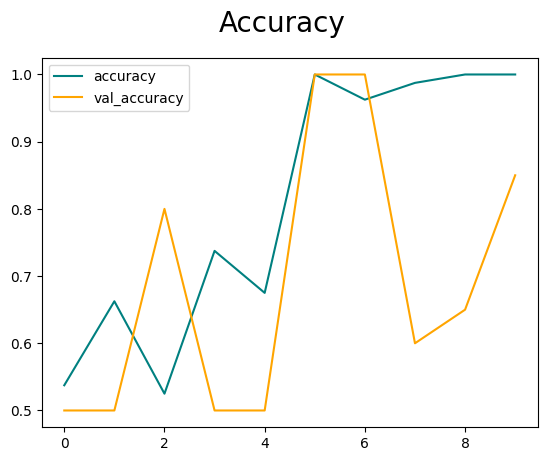

In [31]:
# Plotting Accuracy for Stirling Model ( Has been taken from a tutorial, source has been refrenced in the report)

fig = plt.figure() # creating a new fig object
plt.plot(stirling_hist.history['accuracy'], color='teal', label='accuracy') # plotting the training accuracy
plt.plot(stirling_hist.history['val_accuracy'], color='orange', label='val_accuracy') # plotting the validation accuracy
fig.suptitle('Accuracy', fontsize=20) # put the title as accuracy
plt.legend(loc="upper left") # positioning legend to the upper left corner
plt.show() # this displays the graph

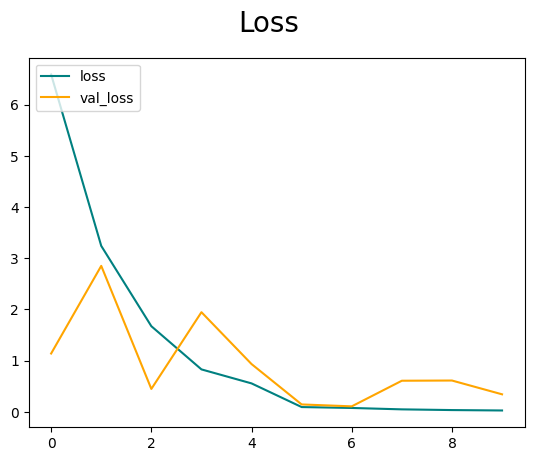

In [32]:
# Plotting the Loss for Stirling model ( Has been taken from a tutorial, source has been refrenced in the report)


fig = plt.figure() # creating a new fig object
plt.plot(stirling_hist.history['loss'], color='teal', label='loss')  # plotting the training loss
plt.plot(stirling_hist.history['val_loss'], color='orange', label='val_loss')  # plotting the validation loss
fig.suptitle('Loss', fontsize=20)  # put the title as loss
plt.legend(loc="upper left") # positioning legend to the upper left corner
plt.show() # this displays the graph

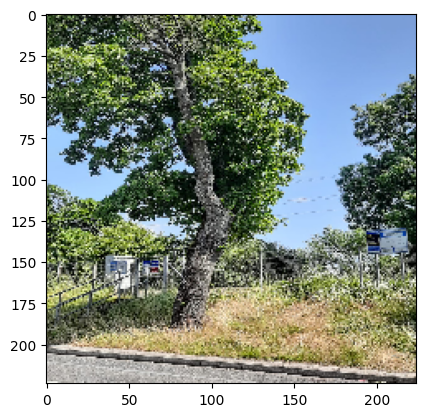

1/1 [==============================] - 0s 71ms/step
Stirling model says it is a : tree


In [33]:
# perdictiing the images of Stirling test set
import random
import matplotlib.pyplot as plt
# own code
batch_x, batch_y = next(stirling_test_set) # retriving the next batch of images from the stirling test set
batch_size = len(batch_x)  # getting the actual batch size
idx2 = random.randint(0, batch_size - 1)  # generating a random index within the valid range

# displaying the image
plt.imshow(batch_x[idx2])
plt.show()


# prediction on the selected image (part taken from a Solution - CNN Image Classificationand has been referenced in report)
# making a prediction on a selected image by passing it to the stirling model
y_pred = stirling_model.predict(batch_x[idx2].reshape(1, 224, 224, 3)) # image is reshaped to match the expected input shape of the model.
y_pred = y_pred > 0.5 # applying a threshold of 0.5

if(y_pred == 0):  # if y_pred is 0 or below 0.5
    pred = 'car'
else:
    pred = 'tree'

print("Stirling model says it is a :", pred)

---

# E2. **Kerala**

Evaluating the Precision, Recall and Accuracy of the kerala model

In [21]:
# calculating the Precision, Recall and Accuracy for kerala Model
pre = tf.keras.metrics.Precision()
re = tf.keras.metrics.Recall()
acc = tf.keras.metrics.BinaryAccuracy()

steps = len(kerala_test_set)

for batch in kerala_test_set:
    X, y = batch
    yhat = kerala_model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

    steps -= 1
    if steps == 0:
        break

precision = pre.result().numpy()
recall = re.result().numpy()
accuracy = acc.result().numpy()

print("For the Kerala Model:")
print("Precision:", precision, "Recall:", recall, "Accuracy:", accuracy)

1/1 [==============================] - 0s 218ms/step
For the Kerala Model:
Precision: 0.9433962 Recall: 1.0 Accuracy: 0.97


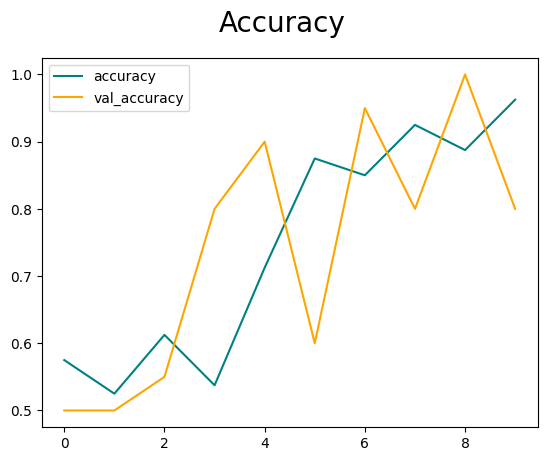

In [22]:
# Accuracy for kerala Model

fig = plt.figure()
plt.plot(kerala_hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(kerala_hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

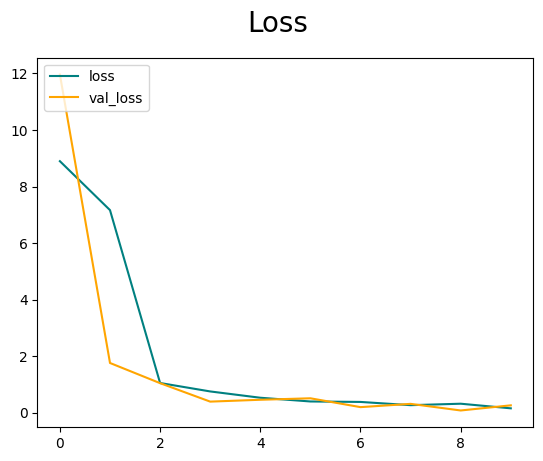

In [23]:
# Plotting Loss for kerala model

fig = plt.figure()
plt.plot(kerala_hist.history['loss'], color='teal', label='loss')
plt.plot(kerala_hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

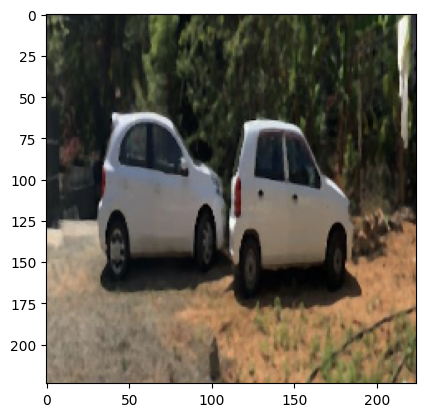

1/1 [==============================] - 0s 51ms/step
Kerala model says it is a : car


In [66]:
# perdictiing the images of kerala test set
import random
import matplotlib.pyplot as plt

batch_x, batch_y = next(kerala_test_set)
batch_size = len(batch_x)
idx2 = random.randint(0, batch_size - 1)

# Display the image
plt.imshow(batch_x[idx2])
plt.show()


# Predict on the selected image
y_pred = kerala_model.predict(batch_x[idx2].reshape(1, 224, 224, 3))
y_pred = y_pred > 0.5

if(y_pred == 0):
    pred = 'car'
else:
    pred = 'tree'

print("Kerala model says it is a :", pred)

  - *E3* - Testing the models crossing datasets. Here you must do exactly the same as in *E2*, but now training in one city and testing in the other. **The model trained in location A must be tested in location B. The model trained in location B must be tested in location A.** Use the same metrics and plot the same types of graphs so that results are comparable.

[top](scrollTo=4i5afvUbhmGo)

---

# E3. **Kerala (Train) - Stirling (Test)**

Created a Model using kerala's train set and stirling's val set and evaluated on stirling's test set.

In [68]:
stirling_kerala_hist1 = kerala_model.fit(kerala_train_set, validation_data = stirling_val_set, epochs = 10, batch_size= 32)

Epoch 1/10
3/3 [==============================] - 16s 6s/step - loss: 0.0108 - accuracy: 1.0000 - val_loss: 0.5320 - val_accuracy: 0.7500
Epoch 2/10
3/3 [==============================] - 11s 4s/step - loss: 0.0242 - accuracy: 0.9875 - val_loss: 0.5348 - val_accuracy: 0.7000
Epoch 3/10
3/3 [==============================] - 12s 3s/step - loss: 0.0110 - accuracy: 1.0000 - val_loss: 0.7769 - val_accuracy: 0.5500
Epoch 4/10
3/3 [==============================] - 11s 4s/step - loss: 0.0216 - accuracy: 1.0000 - val_loss: 0.3259 - val_accuracy: 0.8500
Epoch 5/10
3/3 [==============================] - 12s 3s/step - loss: 0.0360 - accuracy: 0.9750 - val_loss: 1.5355 - val_accuracy: 0.5000
Epoch 6/10
3/3 [==============================] - 11s 3s/step - loss: 0.0476 - accuracy: 0.9875 - val_loss: 0.9369 - val_accuracy: 0.6000
Epoch 7/10
3/3 [==============================] - 11s 3s/step - loss: 0.0646 - accuracy: 0.9875 - val_loss: 0.5129 - val_accuracy: 0.7000
Epoch 8/10
3/3 [==================

---

# E3. **Kerala (Train) - Stirling (Test)**

Evaluating the Precision, Recall and Accuracy from model that was trained on kerala's train set and evaluated on stirling's test set.

In [69]:
# calculating the Precision, Recall and Accuracy for Model using stirling test set
pre = tf.keras.metrics.Precision()
re = tf.keras.metrics.Recall()
acc = tf.keras.metrics.BinaryAccuracy()

steps = len(stirling_test_set)

for batch in stirling_test_set:
    X, y = batch
    yhat = kerala_model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

    steps -= 1
    if steps == 0:
        break

precision = pre.result().numpy()
recall = re.result().numpy()
accuracy = acc.result().numpy()

print("For the Model trained using Kerala's Train set and Stirling's validation set")
print("The results on the Stirling test set is: ")
print("Precision:", precision, "Recall:", recall, "Accuracy:", accuracy)

1/1 [==============================] - 1s 1s/step
For the Model trained using Kerala's Train set and Stirling's validation set
The results on the Stirling test set is: 
Precision: 0.6944444 Recall: 0.98039216 Accuracy: 0.77


# E3. **Kerala (Train) - Stirling (Test)**

Plotting the accuracy of the model Kerala Train and Stirling Test

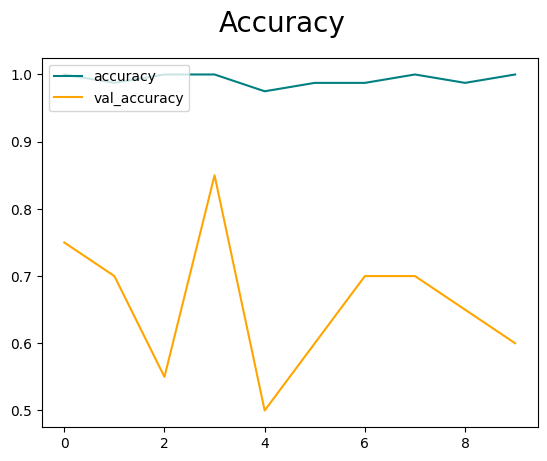

In [70]:
fig = plt.figure()
plt.plot(stirling_kerala_hist1.history['accuracy'], color='teal', label='accuracy')
plt.plot(stirling_kerala_hist1.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# E3. **Kerala (Train) - Stirling (Test)**

Plotting the loss of the model Kerala Train and Stirling Test

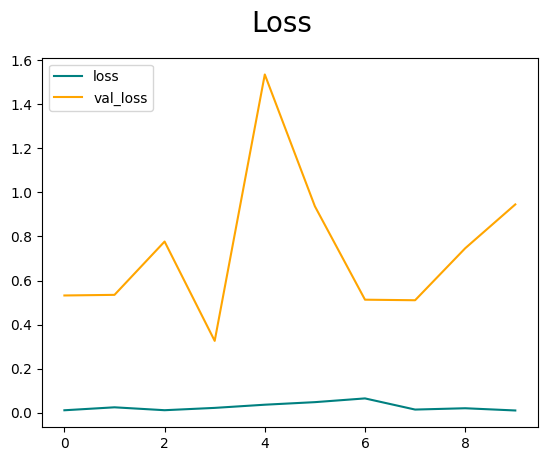

In [71]:
fig = plt.figure()
plt.plot(stirling_kerala_hist1.history['loss'], color='teal', label='loss')
plt.plot(stirling_kerala_hist1.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# E3. **Kerala (Train) - Stirling (Test)**

Model Predicition

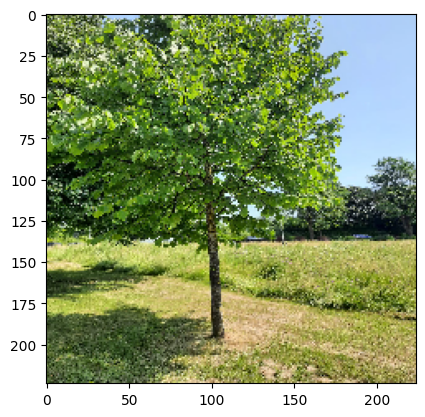

1/1 [==============================] - 0s 94ms/step
Kerala (Train) - Stirling (Test) model says it is a : tree


In [79]:
# perdictiing the images of Stirling test set using the trained kerala model
import random
import matplotlib.pyplot as plt

batch_x, batch_y = next(stirling_test_set)
batch_size = len(batch_x)
idx2 = random.randint(0, batch_size - 1)

# displaying the image
plt.imshow(batch_x[idx2])
plt.show()


# predicting on the selected image
y_pred = kerala_model.predict(batch_x[idx2].reshape(1, 224, 224, 3))
y_pred = y_pred > 0.5

if(y_pred == 0):
    pred = 'car'
else:
    pred = 'tree'

print("Kerala (Train) - Stirling (Test) model says it is a :", pred)

# E3. **Stirling (train) - Kerala (test)**

Created a Model using stirling's train set and kerala's val set and evaluated on kerala's test set.

In [22]:
stirling_kerala_hist2 = stirling_model.fit(stirling_train_set, validation_data = kerala_val_set, epochs = 10, batch_size= 32)

Epoch 1/10
3/3 [==============================] - 14s 5s/step - loss: 0.0036 - accuracy: 1.0000 - val_loss: 0.1362 - val_accuracy: 0.9500
Epoch 2/10
3/3 [==============================] - 12s 4s/step - loss: 0.0021 - accuracy: 1.0000 - val_loss: 0.1407 - val_accuracy: 0.9500
Epoch 3/10
3/3 [==============================] - 15s 5s/step - loss: 0.0120 - accuracy: 1.0000 - val_loss: 0.2918 - val_accuracy: 0.9000
Epoch 4/10
3/3 [==============================] - 14s 5s/step - loss: 0.0049 - accuracy: 1.0000 - val_loss: 0.4978 - val_accuracy: 0.8000
Epoch 5/10
3/3 [==============================] - 12s 3s/step - loss: 0.0153 - accuracy: 0.9875 - val_loss: 0.2260 - val_accuracy: 0.9000
Epoch 6/10
3/3 [==============================] - 11s 3s/step - loss: 0.0039 - accuracy: 1.0000 - val_loss: 0.1344 - val_accuracy: 0.9500
Epoch 7/10
3/3 [==============================] - 11s 4s/step - loss: 0.0194 - accuracy: 0.9875 - val_loss: 0.2836 - val_accuracy: 0.9000
Epoch 8/10
3/3 [==================

# E3. **Stirling (train) - Kerala (test)**

Evaluating the Precision, Recall and Accuracy from model that was trained on stilring's train set and evaluated on kerala's test set.

In [23]:
# calculating the Precision, Recall and Accuracy for Stirling Model using stirling test set
pre = tf.keras.metrics.Precision()
re = tf.keras.metrics.Recall()
acc = tf.keras.metrics.BinaryAccuracy()

steps = len(kerala_test_set)

for batch in kerala_test_set:
    X, y = batch
    yhat = stirling_model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

    steps -= 1
    if steps == 0:
        break

precision = pre.result().numpy()
recall = re.result().numpy()
accuracy = acc.result().numpy()


print("For the Model trained using Stilring's Train set and kerala's validation set")
print("The results on the Kerala test set is: ")
print("Precision:", precision, "Recall:", recall, "Accuracy:", accuracy)

1/1 [==============================] - 0s 68ms/step
For the Model trained using Stilring's Train set and kerala's validation set
The results on the Kerala test set is: 
Precision: 0.9433962 Recall: 1.0 Accuracy: 0.97


# E3. **Stirling (train) - Kerala (test)**

Plotting Accuracy

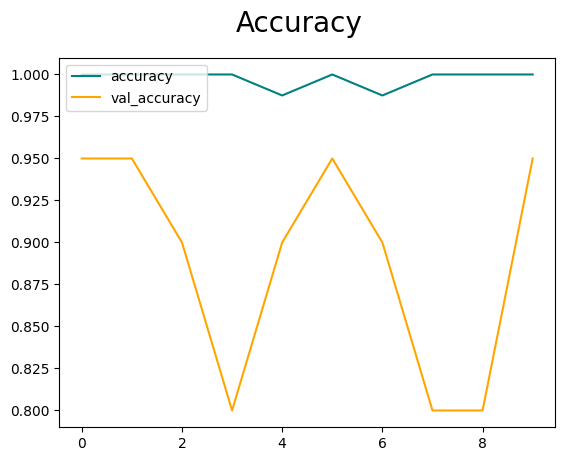

In [35]:
fig = plt.figure()
plt.plot(stirling_kerala_hist2.history['accuracy'], color='teal', label='accuracy')
plt.plot(stirling_kerala_hist2.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# E3. **Stirling (train) - Kerala (test)**

Plotting Loss

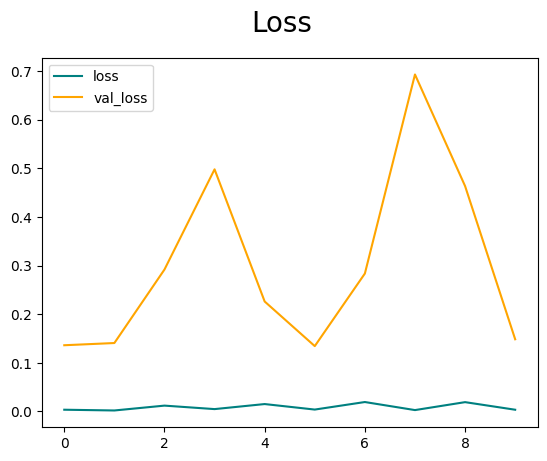

In [36]:
fig = plt.figure()
plt.plot(stirling_kerala_hist2.history['loss'], color='teal', label='loss')
plt.plot(stirling_kerala_hist2.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

# E3. **Stirling (train) - Kerala (test)**

Predicting the Images

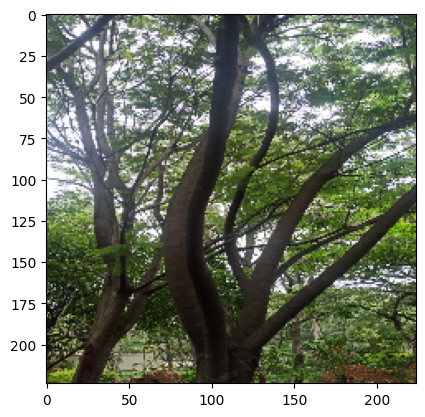

1/1 [==============================] - 0s 57ms/step
Stirling (train) - Kerala (test)model says it is a : tree


In [37]:
# Write your codes for E3 here. Create more code cells if needed
# perdictiing the images of kerala test set using stirling model
import random
import matplotlib.pyplot as plt

batch_x, batch_y = next(kerala_test_set)
batch_size = len(batch_x)
idx2 = random.randint(0, batch_size - 1)

# Display the image
plt.imshow(batch_x[idx2])
plt.show()


# Predict on the selected image
y_pred = stirling_model.predict(batch_x[idx2].reshape(1, 224, 224, 3))
y_pred = y_pred > 0.5

if(y_pred == 0):
    pred = 'car'
else:
    pred = 'tree'

print("Stirling (train) - Kerala (test)model says it is a :", pred)

---

# 7. **Quiz and Report**

Answer the assessment quiz that will be made available on Canvas one week before the final deadline. Make a 2-page latex report using the [IEEE template](https://www.overleaf.com/read/hkfsjjsxmxcn) with a maximum of 1000 words. You can deliver the report in MS Word if you prefer. Your report should contain five sections: introduction, description of the proposed solution with justifications, results (here you can include the same graphs and pictures generated in this jupyter notebook), discussion of the results, and conclusion. Properly cite references to articles, tutorials, and sources used. A pdf version of your report should be made available in the project's github repository under the name "[project name] + _final_report.pdf".


[top](#scrollTo=4i5afvUbhmGo)

In [ ]:
# This notebook will be uploaded in canvas and the repository.
# Name : Sonal Edwin
# Student Id: 3037530